Imports

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Constants and Global variables

In [11]:
# Constants
EXPRESSION_FILE = "C:\\Users\\Ana\\Documents\\Estágio\\Aldinger2020\\Aldinger2020_Temporal_cortex\\Expression_TE_DESeq_Temporal_cortex.csv"
DEA_FILE = "C:\\Users\\Ana\\Documents\\Estágio\\Aldinger2020\\Aldinger2020_Temporal_cortex\\DEA_TE_DESeq_Temporal_cortex.csv"
CLINICAL_DATA = "C:\\Users\\Ana\\Documents\\Estágio\\Aldinger2020\\SraRunTable_Aldinger20.csv"
INTERGENIC_FILE = "C:\\Users\\Ana\\Documents\\Estágio\\Aldinger2020\\TE_Intergenic_With_Distances_Temporal_cortex.bed"

# Variables
expression_df = None
dea_df = None
genes_of_interest = None

Expression - Import

In [12]:
expression_df = pd.read_csv(EXPRESSION_FILE)
expression_df.rename(columns = {'Unnamed: 0' : 'TE'}, inplace = True)
expression_df.head()

,TE,1038_CTL_TCTX,1614_CTL_TCTX,4724_CTL_TCTX,4725_CTL_TCTX,6355_RTT_TCTX,7773_RTT_TCTX,7783_RTT_TCTX,B7992_RTT_TCTX
0,TE_L1MC3_dup2,4,2,0,2,0,2,2,0
1,TE_MER4A1_dup1,4,0,0,3,0,2,1,3
2,TE_L1PA7_dup3,2,2,1,0,2,1,3,5
3,TE_Tigger5_dup3,8,19,9,7,55,14,9,8
4,TE_L1PA7_dup5,3,0,6,1,0,0,1,2


DEA - Import

In [13]:
dea_df = pd.read_csv(DEA_FILE)
dea_df.rename(columns = {'Unnamed: 0' : 'TE'}, inplace = True)
dea_df.dropna(subset =['padj'], inplace = True)
dea_df.head()

,TE,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,TE_AluSx1_dup72547,10.035199,3.416628,0.755915,4.519860,0.000006,0.038761
1,TE_L3_dup25284,15.805777,4.077005,0.906477,4.497636,0.000007,0.038761
2,TE_MLT1J_dup9980,19.067156,2.297392,0.510927,4.496514,0.000007,0.038761
3,TE_HERVL-int_dup2102,39.818987,-3.350906,0.743814,-4.505031,0.000007,0.038761
4,TE_AluSx3_dup9571,6.475171,5.501450,1.265076,4.348713,0.000014,0.040254


Volcano plot

Classification
Non-significant    22430
Up-regulated          10
Down-regulated         5
Name: count, dtype: int64
15
Total tes:
53820
4924
         0          1          2                    TE      4  5     6     7  \
0     chr1   10390888   10391073       TE_L1M4a1_dup14    791  +    L1  LINE   
1     chr1   19293840   19294040      TE_AluJb_dup1496   1054  -   Alu  SINE   
2     chr1   19294271   19294461  TE_HUERS-P3-int_dup1   1155  -  ERV1   LTR   
3     chr1   19294463   19295631  TE_HUERS-P3-int_dup2   4620  -  ERV1   LTR   
4     chr1   19295640   19295844  TE_HUERS-P3-int_dup3    961  -  ERV1   LTR   
...    ...        ...        ...                   ...    ... ..   ...   ...   
1279  chrX  135026425  135027487      TE_L1PB2_dup2856   5963  +    L1  LINE   
1280  chrX  135957031  135958994     TE_L1MC3_dup13226  12844  +    L1  LINE   
1281  chrX  136805441  136805991     TE_MER41A_dup2595   4050  +  ERV1   LTR   
1282  chrX  149225972  149230648     TE_L1PA10_dup7225  171

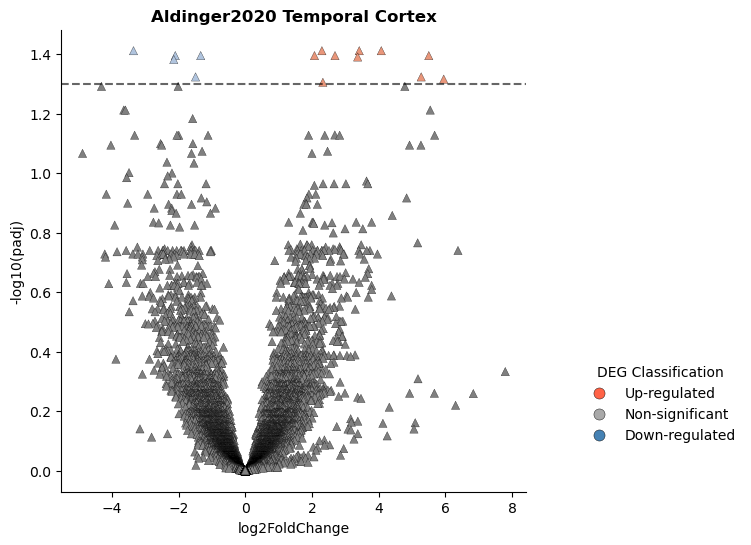

In [19]:

# Organizes the classification, according to the defined values
def organize_classification():
    dea_df['-log10(padj)'] = -np.log10(dea_df['padj'])

    dea_df['Classification'] = dea_df.apply(
        lambda row:
        'Up-regulated' if (row['log2FoldChange'] > 0 and row['padj'] < 0.05)
        else 'Down-regulated' if (row['log2FoldChange'] < -0 and row['padj'] < 0.05)
        else 'Non-significant',
        axis = 1
    )

# Sets the graph's reference lines and labels
def set_lines_and_labels(ax):
    ax.axhline(y = -np.log10(0.05), color = 'black', linestyle = '--', alpha = 0.6)

    ax.set_title('Aldinger2020 Temporal Cortex', fontweight = 'bold', fontsize = 12)
    ax.set_xlabel('log2FoldChange')
    ax.set_ylabel('-log10(padj)')

# Gets the genes with the biggest change in expression
def get_genes_of_interest():
    significant_df = dea_df[dea_df['Classification'] != 'Non-significant']
    top_up = significant_df.nlargest(5, 'log2FoldChange')['TE'].tolist()
    top_down = significant_df.nsmallest(5, 'log2FoldChange')['TE'].tolist()
    genes_of_interest = top_up + top_down

    dea_df['Classification'] = np.where(dea_df['TE'].isin(genes_of_interest), 
                                        'GOI_' + dea_df['Classification'],
                                        dea_df['Classification'])
    
    return genes_of_interest

# Sets the genes of interest's names on the graph
def set_genes_of_interest_legend(ax):
    global genes_of_interest
    genes_of_interest = get_genes_of_interest()
    texts = []
    for i, row in dea_df.iterrows():
        if row['TE'] in genes_of_interest:
            texts.append(ax.text(row['log2FoldChange'], row['-log10(padj)'], row['TE'],
                         fontsize = 7, color = 'black', fontweight = 'semibold'))
            
    adjust_text(texts, expand_points = (1.5, 1.5), arrowprops = dict(arrowstyle = '-', color = 'black', lw = 0.8), save_steps = False)
    print(texts)

# Sets the main chart legend on the plot
def set_plot_legends(ax):
    #set_genes_of_interest_legend(ax)
    legend_elements = [Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'tomato',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3, 
                            label = 'Up-regulated'),
                    Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'darkgray',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3,
                            label = 'Non-significant'),
                    Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'steelblue',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3,
                            label = 'Down-regulated')]
    ax.legend(handles = legend_elements, title = 'DEG Classification', bbox_to_anchor = (1.1, 0.3), frameon = False)


# Main function, gets the volcano plot
def get_volcano_plot():
    organize_classification() # Organiza-se primeiro a tabela com a classificação
    print(dea_df['Classification'].value_counts())
    
    subset = dea_df[dea_df['Classification'] != 'Non-significant']
    print(len(subset))
    print('Total tes:')
    print(len(expression_df))
    
    intergenic_df = pd.read_csv(INTERGENIC_FILE, sep = '\t', header = None, comment = '#')
    intergenic_df = intergenic_df[intergenic_df.iloc[:, -1] > 4000]
    print(intergenic_df.shape[0])

    intergenic_df = intergenic_df.rename(columns = {intergenic_df.columns[3] : 'TE'})
    intergenic_dete_df = intergenic_df.merge(dea_df, on = 'TE', how = 'inner')
    print(intergenic_dete_df)
    intergenic_dete_df = intergenic_dete_df[intergenic_dete_df['Classification'] != 'Non-significant']
    print('intergenic dete')
    print(intergenic_dete_df.shape[0])

    fig, ax = plt.subplots(figsize = (6, 6)) # Criamos o gráfico
    
    palette_dea = {'GOI_Up-regulated' : 'tomato',
                   'GOI_Down-regulated' : 'steelblue',
                   'Up-regulated' : 'darksalmon',
                   'Down-regulated' : 'lightsteelblue',
                   'Non-significant' : 'gray'}
    
    sns.scatterplot(data = dea_df,  
                    x = 'log2FoldChange', 
                    y = '-log10(padj)',
                    palette = palette_dea, 
                    hue = 'Classification', 
                    edgecolor = 'black',
                    linewidth = 0.2, 
                    legend = False, 
                    marker = '^')
    
    set_lines_and_labels(ax) # Colocamos as labels que queremos
    set_plot_legends(ax) # Colocamos as legendas por último
    sns.despine()
    plt.show()
    
get_volcano_plot()



PCA - Data frame

In [20]:
# Variables
TEs = expression_df.iloc[:, 0]
counts = expression_df.iloc[:, 1:]
clinical_data = pd.read_csv(CLINICAL_DATA)

# Process counts
library_size = counts.sum(axis = 0)
cpm_df = counts.div(library_size, axis = 1) * 1e6
log2cpm_df = np.log2(cpm_df + 1)
print(log2cpm_df.head())

# Process clinical data
clinical_data = clinical_data[['Sample_Name', 'Condition', 'Run']]

# Scaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(log2cpm_df.T)

pca = PCA(n_components = 2)
pca_res = pca.fit_transform(scaled_data)

# PCA data frame
pca_df = pd.DataFrame(pca_res, index = log2cpm_df.columns, columns = [f"PC{i+1}" for i in range(2)])
pca_df.reset_index(names = 'Sample_Name', inplace = True)
pca_df = pca_df.merge(clinical_data, on = 'Sample_Name', how = 'left')

pca_df.head()

   1038_CTL_TCTX  1614_CTL_TCTX  4724_CTL_TCTX  4725_CTL_TCTX  6355_RTT_TCTX  \
0       2.291638       2.326723       0.000000       1.588334       0.000000   
1       2.291638       0.000000       0.000000       2.003792       0.000000   
2       1.559765       2.326723       1.077326       0.000000       2.140994   
3       3.136230       5.291240       3.458263       3.004423       6.566710   
4       1.971622       0.000000       2.937482       1.002529       0.000000   

   7773_RTT_TCTX  7783_RTT_TCTX  B7992_RTT_TCTX  
0       1.724497       2.120693        0.000000  
1       1.724497       1.419277        2.094105  
2       1.105896       2.590612        2.689155  
3       4.098668       4.006355        3.280803  
4       0.000000       1.419277        1.668909  


,Sample_Name,PC1,PC2,Condition,Run
0,1038_CTL_TCTX,136.634115,-35.564958,Ctrl,SRR8734764
1,1614_CTL_TCTX,-175.322385,190.233621,Ctrl,SRR8734765
2,4724_CTL_TCTX,111.678596,-1.113304,Ctrl,SRR8734766
3,4725_CTL_TCTX,130.118086,-17.417185,Ctrl,SRR8734767
4,6355_RTT_TCTX,-202.298962,-183.870293,RTT,SRR8734768


PCA - Graph

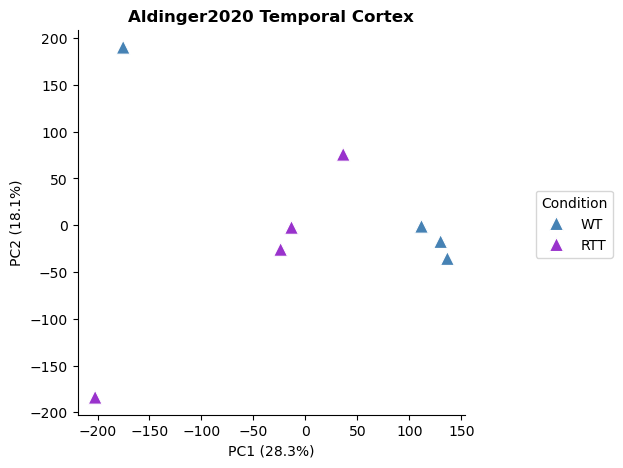

In [21]:
fig, ax = plt.subplots(figsize = (5, 5))
palette_pca = {'WT' : 'steelblue',
               'RTT' : 'darkorchid'}

pca_df['Condition'] = pca_df['Condition'].replace({'Ctrl' : 'WT'})
sns.scatterplot(data = pca_df, x = 'PC1', y = 'PC2', palette = palette_pca, hue = 'Condition', s = 100, marker = '^')
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)") # f-string é uma forma moderna de formatar strings em python, valor da variância * 100 para meter em percentagem e dps coloca só com uma casa decimal
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("Aldinger2020 Temporal Cortex", fontweight = 'bold', fontsize = 12)
ax.legend(title = 'Condition', bbox_to_anchor = (1.4, 0.6))
sns.despine()
plt.show()


Boxplot

     Sample_Name Condition         Run
0  1038_CTL_CCTX      Ctrl  SRR8734756
1  1614_CTL_CCTX      Ctrl  SRR8734757
2  4724_CTL_CCTX      Ctrl  SRR8734758
3  4725_CTL_CCTX      Ctrl  SRR8734759
4  6355_RTT_CCTX       RTT  SRR8734760


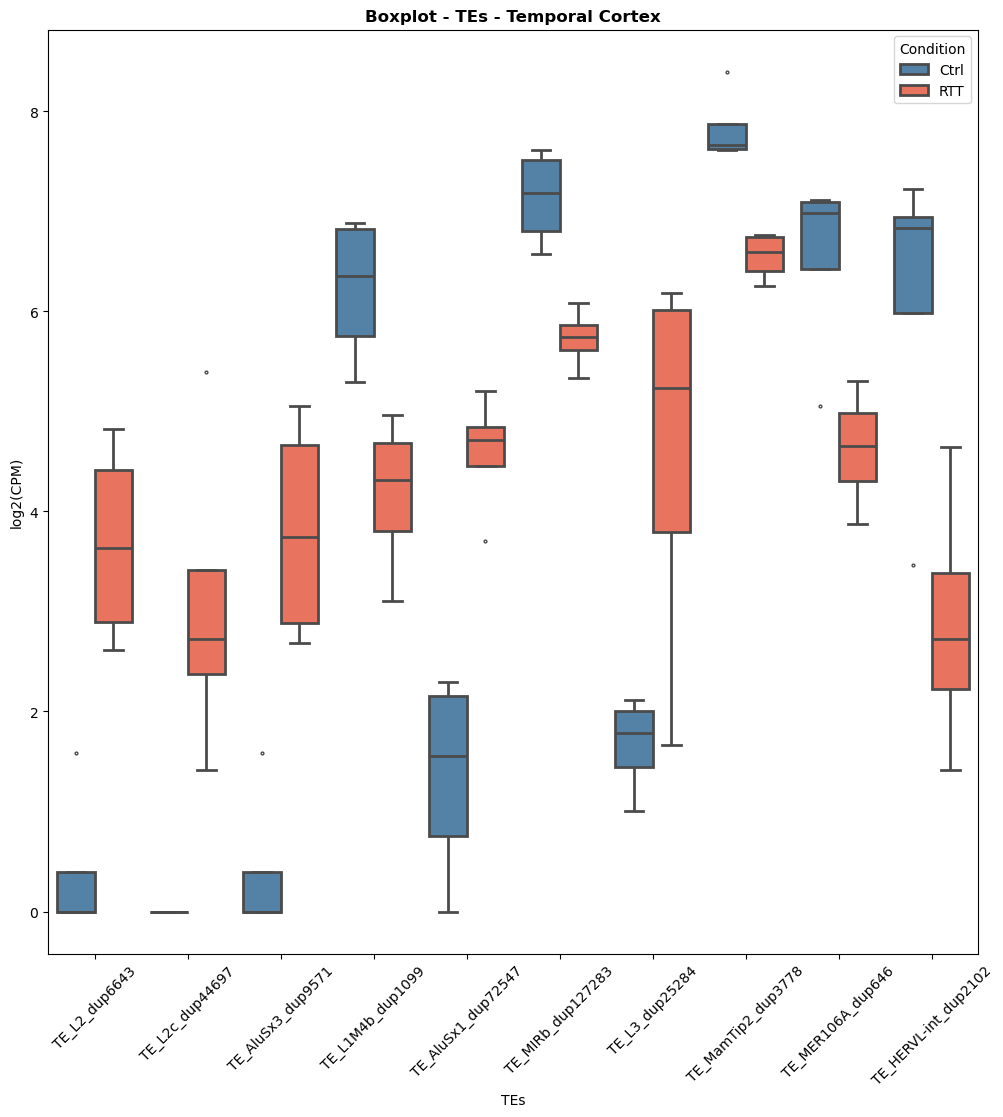

In [22]:
# Assemble the new table
log2cpm_df.insert(0, 'TE', TEs)
goi_df = log2cpm_df[log2cpm_df['TE'].isin(genes_of_interest)]

long_df = goi_df.melt(id_vars = 'TE', var_name = 'Sample_Name', value_name = 'log2(CPM)')
long_df = long_df.merge(clinical_data, on = 'Sample_Name', how = 'left')

print(clinical_data.head())

# Assemble the plot

fig, ax = plt.subplots(figsize = (12, 12))

palette_boxplot = {'RTT' : 'tomato',
                   'Ctrl' : 'steelblue'}

sns.boxplot(data = long_df, x = 'TE', y = 'log2(CPM)', hue = 'Condition', palette = palette_boxplot,
                fliersize = 2, linewidth = 2)

ax.set_title('Boxplot - TEs - Temporal Cortex', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('TEs')
ax.set_ylabel('log2(CPM)')
ax.tick_params(axis = 'x', rotation = 45)

